# Vision Transformer (ViT) — From Scratch on Fashion-MNIST

**Author:** Shivani Bokka
**Dataset:** Fashion-MNIST (28×28 grayscale clothing images, 10 classes)
**Goal:** Build a Vision Transformer from scratch and see how the Transformer architecture from notebook 04 — designed for *text* — can classify *images* by treating an image as a sequence of patches.

---

## What Is This Notebook About?

Notebook 02 classified images with **convolutions**. Notebook 04 built **Transformers** for text. This notebook connects them: the **Vision Transformer** (Dosovitskiy et al., 2020) throws away convolutions entirely and applies a pure Transformer encoder to images.

The trick is one idea: **cut the image into patches, flatten each patch into a vector, and treat the resulting sequence of patch-vectors exactly like a sequence of word-embeddings.** Everything else — self-attention, positional encoding, the `[CLS]` token — is reused directly from the NLP Transformer.

---

## The One-Sentence Idea

> **An image is just a short sentence whose "words" are patches.**

---

## Topics Covered

| # | Section | Key Idea |
|---|---------|----------|
| 1 | Imports and Setup | Libraries, seeds, device |
| 2 | Patch Embedding | Cut the image into patches, embed each one |
| 3 | The ViT Architecture | CLS token, positional embeddings, encoder blocks |
| 4 | Training | Classify Fashion-MNIST from scratch |
| 5 | Accuracy Curves | How training progresses |
| 6 | Attention Maps | Which patches does the model look at? |
| 7 | ViT vs CNN | When each wins |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

plt.rcParams['figure.figsize'] = (10, 5)

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")

CLASSES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


PyTorch version : 2.5.1+cu121
Device          : cuda
GPU name        : NVIDIA GeForce RTX 4060 Laptop GPU




---
## Section 2 — Patch Embedding

A 28×28 image split into **7×7 patches** gives a 4×4 grid = **16 patches**. Each patch (7×7 = 49 pixels) is flattened and passed through a linear layer to become a `dim`-dimensional vector — the image equivalent of a word embedding.

Let's visualize the patch grid first.


  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<02:26, 180kB/s]

  0%|          | 65.5k/26.4M [00:00<02:15, 194kB/s]

  0%|          | 131k/26.4M [00:00<01:30, 290kB/s] 

  1%|          | 229k/26.4M [00:00<00:59, 441kB/s]

...

100%|██████████| 4.42M/4.42M [00:07<00:00, 580kB/s]

Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 5.13MB/s]

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw

Train: 60000  Test: 10000


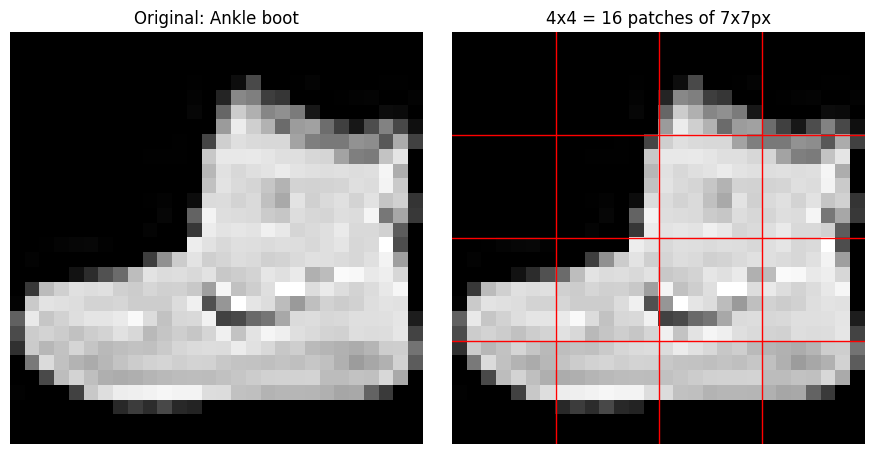

In [2]:
transform = transforms.Compose([transforms.ToTensor()])
train_ds = torchvision.datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.FashionMNIST(root='data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds)}  Test: {len(test_ds)}")

PATCH = 7
GRID = 28 // PATCH  # 4x4 grid of 16 patches

# Visualize the patch decomposition of one image
img, label = train_ds[0]
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(img.squeeze(), cmap='gray'); ax[0].set_title(f'Original: {CLASSES[label]}'); ax[0].axis('off')
ax[1].imshow(img.squeeze(), cmap='gray')
for i in range(1, GRID):
    ax[1].axhline(i * PATCH - 0.5, color='red', lw=1)
    ax[1].axvline(i * PATCH - 0.5, color='red', lw=1)
ax[1].set_title(f'{GRID}x{GRID} = {GRID*GRID} patches of {PATCH}x{PATCH}px'); ax[1].axis('off')
plt.tight_layout(); plt.show()


### How to Read This Chart: Patch Decomposition

- **Left:** the original Fashion-MNIST image.
- **Right:** the same image overlaid with a red grid showing how it's cut into patches.

The Vision Transformer never sees the whole image as a grid of pixels. It sees the **16 patches** as an ordered sequence — patch 1, patch 2, … patch 16 — exactly the way the text Transformer in notebook 04 saw a sequence of tokens. Self-attention then lets every patch look at every other patch.


---


## Section 3 — The ViT Architecture

Putting it together, a ViT is:

1. **Patch embedding** — a single `Conv2d` with `kernel_size = stride = patch_size` does the "cut into patches and linearly embed" step in one operation.
2. **`[CLS]` token** — a learnable vector prepended to the patch sequence; its final state is used for classification (borrowed straight from BERT in notebook 04).
3. **Positional embeddings** — learnable vectors added so the model knows patch order.
4. **Transformer encoder** — the standard multi-head self-attention + MLP blocks.
5. **Classification head** — an MLP on the final `[CLS]` state.


In [3]:
class ViT(nn.Module):
    def __init__(self, img_size=28, patch=7, dim=64, depth=4, heads=4, mlp_dim=128, n_classes=10):
        super().__init__()
        self.n_patches = (img_size // patch) ** 2
        # Patch embedding = conv with stride == kernel == patch size
        self.patch_embed = nn.Conv2d(1, dim, kernel_size=patch, stride=patch)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches + 1, dim))
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)
        # Use PyTorch's built-in encoder layer (batch_first) -- returns attention if we ask a block
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(dim, heads, mlp_dim, dropout=0.1,
                                       activation='gelu', batch_first=True)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, n_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)   # [B, n_patches, dim]
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.norm(x[:, 0]))                 # classify from CLS token

model = ViT().to(device)
print(f"ViT parameters: {sum(p.numel() for p in model.parameters()):,}")
# Shape sanity check
_out = model(torch.randn(4, 1, 28, 28, device=device))
assert _out.shape == (4, 10), f"expected (4,10) got {tuple(_out.shape)}"
print("Output shape check passed:", tuple(_out.shape))


ViT parameters: 139,018


Output shape check passed: (4, 10)




---
## Section 4 — Training

Standard classification training: cross-entropy loss, Adam optimizer. A ViT trained *from scratch* on a small dataset won't beat a CNN (ViTs are famously data-hungry — that's a key lesson of this notebook), but it will learn well enough to classify Fashion-MNIST and, more importantly, to produce interpretable attention maps.


In [4]:
EPOCHS = 12
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

def evaluate(loader):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item(); total += y.size(0)
    return correct / total

train_acc_hist, test_acc_hist = [], []
start = time.time()
for epoch in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        loss = criterion(model(x), y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    tr, te = evaluate(train_loader), evaluate(test_loader)
    train_acc_hist.append(tr); test_acc_hist.append(te)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  train acc {tr:.3f}  test acc {te:.3f}")
print(f"\nTraining time: {time.time()-start:.1f}s  |  Final test accuracy: {test_acc_hist[-1]:.3f}")


Epoch  1/12  train acc 0.798  test acc 0.788


Epoch  2/12  train acc 0.834  test acc 0.826


Epoch  3/12  train acc 0.856  test acc 0.843


Epoch  4/12  train acc 0.863  test acc 0.844


Epoch  5/12  train acc 0.874  test acc 0.857


...

Epoch  8/12  train acc 0.889  test acc 0.867


Epoch  9/12  train acc 0.892  test acc 0.867


Epoch 10/12  train acc 0.895  test acc 0.869


Epoch 11/12  train acc 0.900  test acc 0.875


Epoch 12/12  train acc 0.904  test acc 0.879

Training time: 215.1s  |  Final test accuracy: 0.879


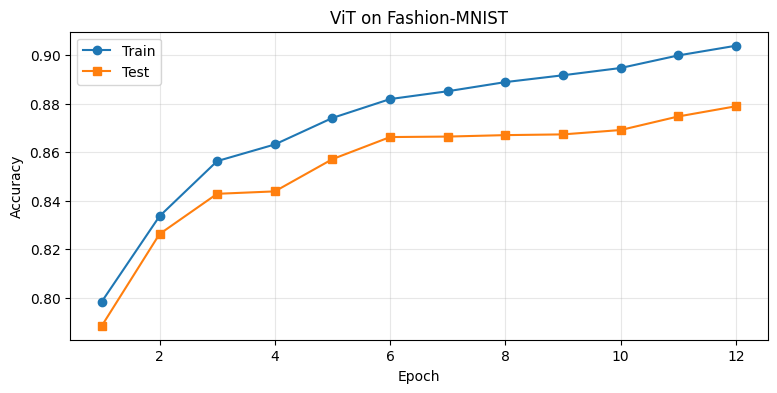

In [5]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), train_acc_hist, marker='o', label='Train')
plt.plot(range(1, EPOCHS+1), test_acc_hist, marker='s', label='Test')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('ViT on Fashion-MNIST')
plt.legend(); plt.grid(alpha=0.3); plt.show()


### How to Read This Chart: Accuracy Curves

- **Train (circles)** and **Test (squares)** accuracy per epoch.
- A healthy run shows both rising together, with a modest gap. A large train-minus-test gap would signal overfitting — a real risk for ViTs on small datasets, which is exactly why the original paper pre-trained on huge datasets before fine-tuning.
- Compare the final test accuracy to notebook 02's CNN: a from-scratch ViT on this little data typically lands *below* a comparable CNN. That underperformance is the lesson, not a bug — **ViTs need scale**.


---


## Section 5 — Attention Maps

The payoff. Because a ViT is built on self-attention, we can ask: **when the `[CLS]` token makes its decision, which image patches did it attend to?** We extract the attention weights from the first encoder block and reshape the CLS-token's attention over the 16 patches back into a 4×4 spatial map, upsampled over the image.


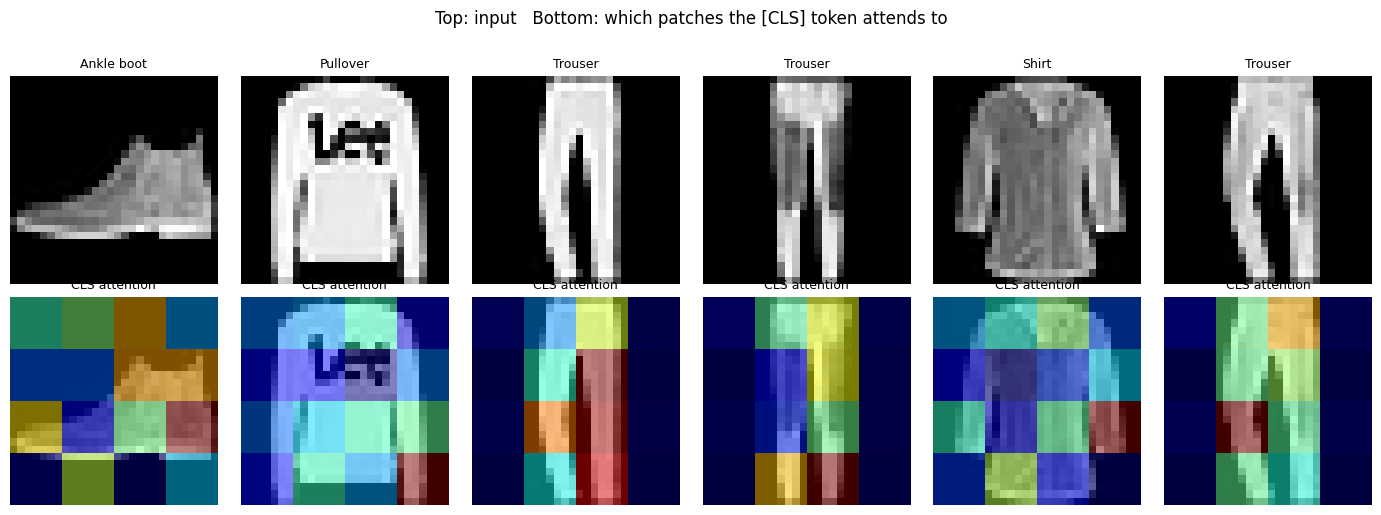

In [6]:
# TransformerEncoderLayer runs attention internally, so to visualize it we re-run the
# first block's self-attention manually, asking for the (head-averaged) weights.
@torch.no_grad()
def cls_attention(model, x):
    model.eval()
    B = x.size(0)
    z = model.patch_embed(x).flatten(2).transpose(1, 2)
    cls = model.cls_token.expand(B, -1, -1)
    z = torch.cat([cls, z], dim=1) + model.pos_embed
    blk = model.blocks[0]
    # Manually invoke the block's self-attention asking for weights, averaged over heads
    _, attn_w = blk.self_attn(z, z, z, need_weights=True, average_attn_weights=True)
    return attn_w  # [B, seq, seq]

# Visualize CLS -> patch attention for 6 test images
imgs = torch.stack([test_ds[i][0] for i in range(6)]).to(device)
labels = [test_ds[i][1] for i in range(6)]
attn = cls_attention(model, imgs)          # [6, 17, 17]
cls_to_patches = attn[:, 0, 1:]            # drop CLS->CLS, keep CLS->16 patches
grid = 28 // 7
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    axes[0, i].imshow(imgs[i].squeeze().cpu(), cmap='gray')
    axes[0, i].set_title(CLASSES[labels[i]], fontsize=9); axes[0, i].axis('off')
    amap = cls_to_patches[i].reshape(grid, grid).cpu().numpy()
    amap = np.kron(amap, np.ones((7, 7)))  # upsample 4x4 -> 28x28
    axes[1, i].imshow(imgs[i].squeeze().cpu(), cmap='gray')
    axes[1, i].imshow(amap, cmap='jet', alpha=0.5)
    axes[1, i].set_title('CLS attention', fontsize=9); axes[1, i].axis('off')
plt.suptitle('Top: input   Bottom: which patches the [CLS] token attends to', y=1.02)
plt.tight_layout(); plt.show()


### How to Read This Chart: Attention Maps

- **Top row:** six test images with their true class.
- **Bottom row:** the same images with a heatmap overlay. Red/bright regions are the patches the `[CLS]` token weights most heavily when forming its representation.

Look at whether the hot patches land on the **discriminative part** of the garment — the ankle of a boot, the sleeve of a shirt, the strap of a bag. This is the ViT analog of the **Grad-CAM** maps from notebook 02: both answer "where is the model looking?", but Grad-CAM derives it from gradients through convolutions, while here it falls straight out of the attention weights — no extra machinery needed. That built-in interpretability is one of ViT's selling points.


---


## Section 6 — ViT vs CNN

| | **CNN** (notebook 02) | **Vision Transformer** (this notebook) |
|---|---|---|
| **Inductive bias** | Strong (locality, translation equivariance built in) | Weak (must learn spatial structure from data) |
| **Data efficiency** | Good on small data | Poor on small data, excellent at scale |
| **Receptive field** | Grows layer by layer | Global from layer 1 (every patch sees every patch) |
| **Interpretability** | Grad-CAM (gradient-based) | Attention maps (built in) |
| **Where it wins** | Limited data, edge devices | Massive datasets, multi-modal models |

**The tradeoff in one line:** the CNN's hard-wired assumptions about images make it sample-efficient but capped; the ViT assumes almost nothing, which hurts on small data but lets it keep improving as data and compute scale — which is why frontier vision and multi-modal models are Transformer-based.

---

## Key Takeaways

1. **An image becomes a sequence of patches** — then it's the same Transformer as notebook 04.
2. **One `Conv2d` implements patch embedding** cleanly.
3. **The `[CLS]` token and positional embeddings** are reused directly from NLP Transformers.
4. **ViTs are data-hungry** — from scratch on small data they trail CNNs; their advantage appears at scale.
5. **Attention maps give interpretability for free**, the ViT counterpart to Grad-CAM.
